# Doctor Pocket — Medical Q&A LLM Fine-Tuning
### QLoRA fine-tuning of Qwen2.5-1.5B-Instruct on a free Google Colab T4 GPU

**Doctor Pocket** is an educational medical question-answering assistant. This notebook fine-tunes
`Qwen/Qwen2.5-1.5B-Instruct` using **QLoRA** (4-bit NF4 quantization + LoRA adapters) on a
medical Q&A dataset, so that the whole pipeline fits comfortably inside a free Colab **T4 GPU (~16 GB VRAM)**.

**Pipeline:**

```
Medical Q&A Dataset (16,406 examples, 9 topics)
        |
80 / 10 / 10 stratified split (by topic)
        |
Qwen2.5-1.5B-Instruct  (4-bit NF4 quantization)
        |
QLoRA fine-tuning (2 epochs)
        |
Evaluation (loss + ROUGE, with caveats)
        |
Save LoRA adapter + tokenizer
        |
ZIP / Download
        |
FastAPI deployment scaffold
```

> ⚠️ **Medical Safety Notice** — Doctor Pocket is a research / educational prototype. It is **not**
> a medical device and **must not** be used for real diagnosis or treatment decisions. See Section 16
> for the full safety statement that is baked into the model's inference-time system prompt.

**How to use this notebook**: Runtime → Change runtime type → **T4 GPU**, then Runtime → Run all.
Every section prints outputs you can use to verify the step worked before moving to the next one.


## 1. Environment Setup

Before installing anything, we check what hardware we actually got. Colab's free tier randomly
assigns a T4, and occasionally something else — we want to know immediately, because our batch
size / quantization choices below are tuned specifically for a T4's ~16 GB of VRAM.

We also fix all random seeds now so that dataset splitting, shuffling, and training are reproducible.


In [1]:
# --- Global reproducibility seed, used throughout the notebook ---
SEED = 42

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

print(f"Global SEED set to {SEED}")


Global SEED set to 42


In [2]:
# --- GPU detection (torch is preinstalled on Colab, so this works before we pin anything) ---
import subprocess

try:
    import torch
    cuda_available = torch.cuda.is_available()
except ImportError:
    torch = None
    cuda_available = False

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    total_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    cuda_version = torch.version.cuda
    torch_version = torch.__version__

    print(f"GPU: {gpu_name}")
    print(f"CUDA available: {cuda_available}")
    print(f"CUDA version: {cuda_version}")
    print(f"PyTorch version: {torch_version}")
    print(f"GPU memory: ~{total_vram_gb:.1f} GB")

    if "T4" not in gpu_name:
        print(f"\nWARNING: This notebook is tuned for an NVIDIA T4 (~16GB). "
              f"You have a '{gpu_name}'. Training should still work, but you may be able to "
              f"increase batch size on a larger GPU, or may need to reduce it on a smaller one.")
    else:
        print("\nConfirmed: NVIDIA T4 GPU detected. Configuration in this notebook targets this GPU.")
else:
    print("WARNING: No GPU detected!")
    print("Go to Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4) and re-run.")
    print("QLoRA fine-tuning of even a 1.5B model on CPU is impractically slow.")

print("=" * 60)


ENVIRONMENT CHECK
GPU: Tesla T4
CUDA available: True
CUDA version: 12.8
PyTorch version: 2.11.0+cu128
GPU memory: ~14.6 GB

Confirmed: NVIDIA T4 GPU detected. Configuration in this notebook targets this GPU.


**Checkpoint:** you should see `GPU: Tesla T4`, `CUDA available: True`, and roughly `~15 GB` of
memory above. If you see the CPU warning, stop here and switch the Colab runtime before continuing.

## 2. Install Dependencies

QLoRA fine-tuning depends on several fast-moving libraries (`transformers`, `trl`, `peft`,
`accelerate`, `bitsandbytes`) that frequently break compatibility with each other. Rather than
relying on whatever happens to be preinstalled on Colab (which changes over time and is a common
source of `Attempting to unscale FP16 gradients` and similar errors), we **pin explicit, mutually
tested versions** below.

We deliberately do **not** reinstall `torch` — Colab's preinstalled PyTorch build is already
compiled against the correct CUDA driver for the T4, and reinstalling it is slow and risks a
CUDA/driver mismatch. We only reinstall the higher-level libraries that sit on top of it.


In [3]:
# ============================================================
# 2. INSTALL DEPENDENCIES
# Doctor Pocket — Qwen2.5-1.5B-Instruct + QLoRA
# Designed for Google Colab NVIDIA T4
# ============================================================

!pip install -q -U \
    "transformers>=4.46,<5.0" \
    "datasets>=2.18,<4.0" \
    "accelerate>=0.34,<2.0" \
    "peft>=0.13,<0.19" \
    "trl>=0.12,<0.20" \
    "bitsandbytes>=0.44,<1.0" \
    "sentencepiece" \
    "huggingface_hub" \
    "evaluate" \
    "rouge_score" \
    "scikit-learn"

In [4]:
import torch
import transformers
import datasets
import accelerate
import peft
import trl
import bitsandbytes
import huggingface_hub

print("=" * 60)
print("DOCTOR POCKET — ENVIRONMENT CHECK")
print("=" * 60)

print(f"PyTorch:          {torch.__version__}")
print(f"Transformers:     {transformers.__version__}")
print(f"Datasets:         {datasets.__version__}")
print(f"Accelerate:       {accelerate.__version__}")
print(f"PEFT:             {peft.__version__}")
print(f"TRL:              {trl.__version__}")
print(f"BitsAndBytes:     {bitsandbytes.__version__}")
print(f"HuggingFace Hub:  {huggingface_hub.__version__}")

print("\n" + "=" * 60)
print("GPU CHECK")
print("=" * 60)

if torch.cuda.is_available():
    print("CUDA available: True")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("WARNING: CUDA GPU not detected!")

print("=" * 60)

DOCTOR POCKET — ENVIRONMENT CHECK
PyTorch:          2.11.0+cu128
Transformers:     4.57.6
Datasets:         3.6.0
Accelerate:       1.14.0
PEFT:             0.18.1
TRL:              0.19.1
BitsAndBytes:     0.50.0
HuggingFace Hub:  0.36.2

GPU CHECK
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


## 3. GPU and Environment Verification

We re-check the GPU now that all libraries are installed, and additionally confirm that
`bitsandbytes` can actually see and use CUDA — this is the library responsible for 4-bit
quantization, and it is the most common source of silent failures in QLoRA setups.


In [5]:
import torch

assert torch.cuda.is_available(), "No GPU available. Set Runtime -> Change runtime type -> GPU."

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
total_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

print(f"Using device: {device}")
print(f"GPU: {gpu_name}")
print(f"Total VRAM: {total_vram_gb:.1f} GB")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (torch build): {torch.version.cuda}")

# bitsandbytes sanity check - this import performs its own internal CUDA setup check
import bitsandbytes as bnb
print(f"bitsandbytes version: {bnb.__version__}")
print("bitsandbytes imported successfully - CUDA kernels are available.")

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f"\ntorch manual seed set to {SEED}")


Using device: cuda
GPU: Tesla T4
Total VRAM: 14.6 GB
PyTorch version: 2.11.0+cu128
CUDA version (torch build): 12.8
bitsandbytes version: 0.50.0
bitsandbytes imported successfully - CUDA kernels are available.

torch manual seed set to 42


## 4. Hugging Face Authentication

`Qwen/Qwen2.5-1.5B-Instruct` is a public model, so authentication is **not strictly required** to
download it. However, logging in is recommended because:

- It raises your Hugging Face Hub download rate limit (avoids throttling).
- It's required later if you want to push the fine-tuned adapter to the Hub.

**Never hard-code a token in a notebook.** Instead, get a free token from
[https://huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) (a "Read" token is
enough) and paste it into the secure prompt below. The input is hidden and is not saved anywhere in
this notebook's cell outputs.


In [6]:
from huggingface_hub import login
import getpass

HF_LOGIN_REQUIRED = True  # set to False to skip login entirely (works fine for a public model)

if HF_LOGIN_REQUIRED:
    try:
        hf_token = getpass.getpass(
            "Paste your Hugging Face token (from https://huggingface.co/settings/tokens), "
            "or leave blank and press Enter to skip: "
        )
        if hf_token.strip():
            login(token=hf_token.strip())
            print("Logged in to Hugging Face Hub.")
        else:
            print("Skipped Hugging Face login. Public model download will still work.")
    except Exception as e:
        print(f"Login skipped due to: {e}. Continuing without authentication.")
else:
    print("HF_LOGIN_REQUIRED is False - skipping login.")


Paste your Hugging Face token (from https://huggingface.co/settings/tokens), or leave blank and press Enter to skip: ··········
Skipped Hugging Face login. Public model download will still work.


## 5. Dataset Loading

This notebook is built around the **`MedicalQuestionAnswering.csv`** dataset. It has four columns:

| column | meaning |
|---|---|
| `Question` | the medical question |
| `Answer` | the reference medical answer |
| `topic` | one of 9 medical topic categories (e.g. `cancer`, `Heart_Lung_Blood`, `Genetic_and_Rare_Diseases`) |
| `split` | a pre-existing `train` / `test` tag shipped with the dataset |

We do **not** hard-code column names blindly — the cell below inspects whatever CSV is uploaded and
only proceeds once it finds columns matching the configuration. This makes the notebook reusable if
you swap in a differently-named CSV later; just edit `QUESTION_COLUMN` / `ANSWER_COLUMN` below.

Upload `MedicalQuestionAnswering.csv` when prompted (or place it at `/content/MedicalQuestionAnswering.csv`
before running this cell, e.g. via Google Drive).


In [7]:
import os
import pandas as pd

DATA_PATH = "/content/MedicalQuestionAnswering.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Dataset not found at", DATA_PATH)
        print("Please upload MedicalQuestionAnswering.csv now:")
        uploaded = files.upload()
        # Move whatever was uploaded to the expected path
        uploaded_name = list(uploaded.keys())[0]
        if uploaded_name != "MedicalQuestionAnswering.csv":
            os.rename(uploaded_name, DATA_PATH)
    except ImportError:
        raise FileNotFoundError(
            f"{DATA_PATH} not found and google.colab.files is unavailable. "
            "Place the CSV at this path manually before re-running."
        )

raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(raw_df):,} rows from {DATA_PATH}")
print(f"Columns: {raw_df.columns.tolist()}")


Loaded 16,406 rows from /content/MedicalQuestionAnswering.csv
Columns: ['Question', 'Answer', 'topic', 'split']


In [8]:
# --- Column configuration ---------------------------------------------------
# Edit these two lines if your CSV uses different column names.
QUESTION_COLUMN = "Question"
ANSWER_COLUMN = "Answer"
TOPIC_COLUMN = "topic"          # optional - used for stratified splitting below, set to None if absent
EXISTING_SPLIT_COLUMN = "split"  # optional - the dataset's own train/test tag, set to None if absent

# Auto-detect fallback: if the configured names aren't present, try common alternatives.
_candidates_q = [QUESTION_COLUMN, "question", "Question", "input", "prompt"]
_candidates_a = [ANSWER_COLUMN, "answer", "Answer", "output", "response"]

if QUESTION_COLUMN not in raw_df.columns:
    QUESTION_COLUMN = next((c for c in _candidates_q if c in raw_df.columns), None)
if ANSWER_COLUMN not in raw_df.columns:
    ANSWER_COLUMN = next((c for c in _candidates_a if c in raw_df.columns), None)
if TOPIC_COLUMN not in raw_df.columns:
    TOPIC_COLUMN = None
if EXISTING_SPLIT_COLUMN not in raw_df.columns:
    EXISTING_SPLIT_COLUMN = None

assert QUESTION_COLUMN is not None, f"Could not find a question column in {raw_df.columns.tolist()}"
assert ANSWER_COLUMN is not None, f"Could not find an answer column in {raw_df.columns.tolist()}"

print(f"QUESTION_COLUMN = '{QUESTION_COLUMN}'")
print(f"ANSWER_COLUMN   = '{ANSWER_COLUMN}'")
print(f"TOPIC_COLUMN    = '{TOPIC_COLUMN}'")
print(f"EXISTING_SPLIT_COLUMN = '{EXISTING_SPLIT_COLUMN}'")


QUESTION_COLUMN = 'Question'
ANSWER_COLUMN   = 'Answer'
TOPIC_COLUMN    = 'topic'
EXISTING_SPLIT_COLUMN = 'split'


## 6. Dataset Inspection

Before touching the data, we look at it: row/column counts, a few raw samples, and the distribution
of question/answer lengths. This tells us whether the sequence length we pick in Section 9 will
truncate a meaningful fraction of examples.


In [9]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total examples: {len(raw_df):,}")
print(f"Columns: {raw_df.columns.tolist()}")
print(f"Null values per column:\n{raw_df.isnull().sum()}")

if TOPIC_COLUMN:
    print(f"\nNumber of unique topics: {raw_df[TOPIC_COLUMN].nunique()}")
    print(f"Topic distribution:\n{raw_df[TOPIC_COLUMN].value_counts()}")

if EXISTING_SPLIT_COLUMN:
    print(f"\nExisting '{EXISTING_SPLIT_COLUMN}' column distribution:\n{raw_df[EXISTING_SPLIT_COLUMN].value_counts()}")


DATASET OVERVIEW
Total examples: 16,406
Columns: ['Question', 'Answer', 'topic', 'split']
Null values per column:
Question    0
Answer      0
topic       0
split       0
dtype: int64

Number of unique topics: 9
Topic distribution:
topic
growth_hormone_receptor          5430
Genetic_and_Rare_Diseases        5388
Diabetes_Digestive_Kidney        1192
Neurological_Disorders_Stroke    1088
Other                             981
SeniorHealth                      769
cancer                            729
Heart_Lung_Blood                  559
Disease_Control_Prevention        270
Name: count, dtype: int64

Existing 'split' column distribution:
split
train    13122
test      3284
Name: count, dtype: int64


In [10]:
print("=" * 60)
print("SAMPLE RECORDS")
print("=" * 60)
for i, row in raw_df.sample(5, random_state=SEED).iterrows():
    print(f"\n--- Row {i} (topic={row[TOPIC_COLUMN] if TOPIC_COLUMN else 'n/a'}) ---")
    print(f"Q: {row[QUESTION_COLUMN][:200]}")
    print(f"A: {str(row[ANSWER_COLUMN])[:300]}{'...' if len(str(row[ANSWER_COLUMN])) > 300 else ''}")


SAMPLE RECORDS

--- Row 3634 (topic=growth_hormone_receptor) ---
Q: What are the treatments for dihydropyrimidinase deficiency ?
A: These resources address the diagnosis or management of dihydropyrimidinase deficiency:  - Genetic Testing Registry: Dihydropyrimidinase deficiency   These resources from MedlinePlus offer information about the diagnosis and management of various health conditions:  - Diagnostic Tests  - Drug Therapy...

--- Row 13745 (topic=Genetic_and_Rare_Diseases) ---
Q: What is (are) Cri du chat syndrome ?
A: Cri du chat syndrome, also known as 5p- (5p minus) syndrome or cat cry syndrome, is a genetic condition that is caused by the deletion of genetic material on the small arm (the p arm) of chromosome 5. Infants with this condition often have a high-pitched cry that sounds like that of a cat. The disor...

--- Row 4395 (topic=growth_hormone_receptor) ---
Q: What is (are) phenylketonuria ?
A: Phenylketonuria (commonly known as PKU) is an inherited disorder that increa

In [11]:
# --- Question / answer length statistics (in characters, then in tokens later in Section 9) ---
q_lens = raw_df[QUESTION_COLUMN].astype(str).str.len()
a_lens = raw_df[ANSWER_COLUMN].astype(str).str.len()

print("Question length (characters):")
print(q_lens.describe())
print("\nAnswer length (characters):")
print(a_lens.describe())


Question length (characters):
count    16406.000000
mean        50.685603
std         16.926775
min         16.000000
25%         38.000000
50%         48.000000
75%         61.000000
max        191.000000
Name: Question, dtype: float64

Answer length (characters):
count    16406.000000
mean      1303.440266
std       1656.744059
min          6.000000
25%        487.000000
50%        890.000000
75%       1589.000000
max      29046.000000
Name: Answer, dtype: float64


### Feature engineering notes

A few things stand out from the inspection above and drive decisions later in the notebook:

1. **Answers vary enormously in length** (some are a few dozen characters, others are 10,000+).
   Very long answers will be truncated at `MAX_SEQ_LENGTH` (Section 9) — we measure exactly how many
   are affected rather than guessing.
2. **`topic` is imbalanced** (`growth_hormone_receptor` and `Genetic_and_Rare_Diseases` dominate).
   We stratify our train/val/test split by `topic` so every split has a proportional mix of all 9
   topics — otherwise a random split could leave rare topics (e.g. `Disease_Control_Prevention`)
   almost entirely out of validation or test.
3. **The dataset ships its own `split` column** (train/test only, no validation, ~80/20). We respect
   the *spirit* of that split (it's already topic-stratified) but re-derive a fresh **80/10/10**
   train/validation/test split ourselves in Section 7, because (a) the notebook needs a validation
   set for monitoring training and (b) 80/10/10 is what this project targets. We do this with a fixed
   `seed=42` so it's fully reproducible.
4. **Duplicate rows**: we drop exact duplicate `(Question, Answer)` pairs before splitting, so the
   same example can't leak across splits.


## 7. Dataset Preprocessing

Basic cleaning before splitting:

1. Drop rows with empty/whitespace-only question or answer.
2. Drop exact duplicate `(Question, Answer)` pairs.
3. Strip leading/trailing whitespace.
4. Keep `topic` around (used for stratification and, optionally, could be prepended to the prompt —
   we choose **not** to do that, since we want the model to answer from the question alone, the way
   a real user would ask it).


In [12]:
clean_df = raw_df.copy()

before = len(clean_df)

# Drop nulls / empty strings
clean_df[QUESTION_COLUMN] = clean_df[QUESTION_COLUMN].astype(str).str.strip()
clean_df[ANSWER_COLUMN] = clean_df[ANSWER_COLUMN].astype(str).str.strip()
clean_df = clean_df[(clean_df[QUESTION_COLUMN].str.len() > 0) & (clean_df[ANSWER_COLUMN].str.len() > 0)]

# Drop exact duplicate Q/A pairs (prevents the same example appearing in two splits later)
clean_df = clean_df.drop_duplicates(subset=[QUESTION_COLUMN, ANSWER_COLUMN]).reset_index(drop=True)

after = len(clean_df)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before - after:,}")

assert after > 0, "All rows were removed during cleaning - check the source CSV."


Rows before cleaning: 16,406
Rows after cleaning:  16,358
Rows removed:         48


## 8. Train / Validation / Test Split

We create an **80 / 10 / 10** train/validation/test split, **stratified by `topic`** so every split
has a proportional mix of all 9 medical topics (important given the class imbalance we saw in
Section 6). The split uses `seed=42` for full reproducibility.

The **test set is held out completely** and is not touched again until Section 16
(Test Set Evaluation) — not for training, not for hyperparameter decisions, not for early stopping.

We also add a stable `example_id` column before splitting and verify there is zero overlap between
the three splits by ID, as an explicit sanity check against data leakage.


In [13]:
from sklearn.model_selection import train_test_split

TRAIN_FRACTION = 0.8
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-9

split_df = clean_df.copy()
split_df["example_id"] = split_df.index.astype(str)

stratify_col = split_df[TOPIC_COLUMN] if TOPIC_COLUMN else None

# First split off the test set (10%)
train_val_df, test_df = train_test_split(
    split_df,
    test_size=TEST_FRACTION,
    random_state=SEED,
    stratify=stratify_col,
)

# Then split the remaining 90% into train (80% of total) and validation (10% of total)
val_relative_fraction = VAL_FRACTION / (TRAIN_FRACTION + VAL_FRACTION)  # 0.10 / 0.90
stratify_col_2 = train_val_df[TOPIC_COLUMN] if TOPIC_COLUMN else None

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_fraction,
    random_state=SEED,
    stratify=stratify_col_2,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train examples:     ", f"{len(train_df):,}")
print("Validation examples:", f"{len(val_df):,}")
print("Test examples:      ", f"{len(test_df):,}")
print(f"\nActual fractions -> train: {len(train_df)/len(split_df):.1%}, "
      f"val: {len(val_df)/len(split_df):.1%}, test: {len(test_df)/len(split_df):.1%}")


Train examples:      13,086
Validation examples: 1,636
Test examples:       1,636

Actual fractions -> train: 80.0%, val: 10.0%, test: 10.0%


In [14]:
# --- Leakage check: verify zero overlap between splits by example_id ---
train_ids = set(train_df["example_id"])
val_ids = set(val_df["example_id"])
test_ids = set(test_df["example_id"])

overlap_train_val = train_ids & val_ids
overlap_train_test = train_ids & test_ids
overlap_val_test = val_ids & test_ids

assert not overlap_train_val, f"Leakage between train/val: {overlap_train_val}"
assert not overlap_train_test, f"Leakage between train/test: {overlap_train_test}"
assert not overlap_val_test, f"Leakage between val/test: {overlap_val_test}"

print("No overlap between train/validation/test splits. Leakage check passed.")

if TOPIC_COLUMN:
    print("\nTopic distribution per split (proportions should look similar across rows):")
    import pandas as pd
    dist = pd.DataFrame({
        "train": train_df[TOPIC_COLUMN].value_counts(normalize=True),
        "val": val_df[TOPIC_COLUMN].value_counts(normalize=True),
        "test": test_df[TOPIC_COLUMN].value_counts(normalize=True),
    }).fillna(0).round(3)
    print(dist)


No overlap between train/validation/test splits. Leakage check passed.

Topic distribution per split (proportions should look similar across rows):
                               train    val   test
topic                                             
growth_hormone_receptor        0.332  0.332  0.332
Genetic_and_Rare_Diseases      0.329  0.329  0.329
Diabetes_Digestive_Kidney      0.070  0.070  0.070
Neurological_Disorders_Stroke  0.066  0.067  0.067
Other                          0.060  0.060  0.060
SeniorHealth                   0.047  0.047  0.047
cancer                         0.045  0.045  0.045
Heart_Lung_Blood               0.034  0.034  0.034
Disease_Control_Prevention     0.017  0.017  0.017


## 9. Prompt Format

`Qwen2.5-1.5B-Instruct` was itself instruction-tuned using a specific chat template (ChatML-style,
with `<|im_start|>` / `<|im_end|>` turn markers). We must format our training examples the **same
way** the base model already expects, using `tokenizer.apply_chat_template(...)` rather than
inventing our own format — otherwise we're fighting the model's existing instruction-following prior
instead of building on it.

Each example becomes a 3-turn conversation:

```
system: <Doctor Pocket system prompt>
user:   <medical question>
assistant: <medical answer>
```

We define the **system prompt once, here**, and reuse the exact same string both during training and
later during inference (Sections 21-23) — it's important that training-time and inference-time
prompts match, otherwise the fine-tuned behavior won't transfer cleanly.


In [15]:
# The Doctor Pocket system prompt - used identically at training time and inference time.
# See Section 17 for the full medical-safety rationale behind this prompt.
DOCTOR_POCKET_SYSTEM_PROMPT = (
    "You are Doctor Pocket, an AI medical information assistant. "
    "Provide clear, cautious, educational medical information. "
    "Do not claim to replace a doctor. "
    "For emergencies or serious symptoms, advise the user to seek professional medical care. "
    "Do not invent medical facts."
)

print(DOCTOR_POCKET_SYSTEM_PROMPT)


You are Doctor Pocket, an AI medical information assistant. Provide clear, cautious, educational medical information. Do not claim to replace a doctor. For emergencies or serious symptoms, advise the user to seek professional medical care. Do not invent medical facts.


In [16]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Qwen2.5-Instruct ships a pad token already, but we guard against models that don't.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
print(f"PAD token: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print(f"Chat template available: {tokenizer.chat_template is not None}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: Qwen/Qwen2.5-1.5B-Instruct
Vocab size: 151643
EOS token: '<|im_end|>' (id=151645)
PAD token: '<|endoftext|>' (id=151643)
Chat template available: True


In [17]:
def build_conversation(question: str, answer: str) -> str:
    """Turn a (question, answer) pair into a formatted training string using
    Qwen2.5-Instruct's own chat template."""
    messages = [
        {"role": "system", "content": DOCTOR_POCKET_SYSTEM_PROMPT},
        {"role": "user", "content": question},
        {"role": "assistant", "content": answer},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False)


def build_prompt_only(question: str) -> str:
    """Same conversation but WITHOUT the assistant turn, and with a generation
    prompt appended - this is what we feed the model at inference/evaluation time."""
    messages = [
        {"role": "system", "content": DOCTOR_POCKET_SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


# Sanity-check on one real example
_sample_text = build_conversation(train_df.iloc[0][QUESTION_COLUMN], train_df.iloc[0][ANSWER_COLUMN])
print("EXAMPLE FORMATTED CONVERSATION:")
print("-" * 60)
print(_sample_text[:800])
print("-" * 60)


EXAMPLE FORMATTED CONVERSATION:
------------------------------------------------------------
<|im_start|>system
You are Doctor Pocket, an AI medical information assistant. Provide clear, cautious, educational medical information. Do not claim to replace a doctor. For emergencies or serious symptoms, advise the user to seek professional medical care. Do not invent medical facts.<|im_end|>
<|im_start|>user
What are the treatments for neuromyelitis optica ?<|im_end|>
<|im_start|>assistant
These resources address the diagnosis or management of neuromyelitis optica:  - Genetic Testing Registry: Neuromyelitis optica  - National Institute of Neurological Disorders and Stroke: Neuromyelitis Optica Information Page  - The Transverse Myelitis Association: Acute Treatments   These resources from MedlinePlus offer information about the diagnosis and management of various health conditions:  -
------------------------------------------------------------


We now convert the three pandas splits into 🤗 `datasets.Dataset` objects and apply
`build_conversation` to create a single `text` column — this is the field `SFTTrainer` will consume
directly in Section 14.


In [18]:
from datasets import Dataset, DatasetDict

def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[[QUESTION_COLUMN, ANSWER_COLUMN, "example_id"]].reset_index(drop=True))
    ds = ds.map(
        lambda ex: {"text": build_conversation(ex[QUESTION_COLUMN], ex[ANSWER_COLUMN])},
        desc="Formatting conversations",
    )
    return ds

raw_datasets = DatasetDict({
    "train": to_hf_dataset(train_df),
    "validation": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
})

print(raw_datasets)
print("\nColumn names:", raw_datasets["train"].column_names)
print("\nFeatures:", raw_datasets["train"].features)
print("\nFirst training record (text field):")
print(raw_datasets["train"][0]["text"][:500])


Formatting conversations:   0%|          | 0/13086 [00:00<?, ? examples/s]

Formatting conversations:   0%|          | 0/1636 [00:00<?, ? examples/s]

Formatting conversations:   0%|          | 0/1636 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Question', 'Answer', 'example_id', 'text'],
        num_rows: 13086
    })
    validation: Dataset({
        features: ['Question', 'Answer', 'example_id', 'text'],
        num_rows: 1636
    })
    test: Dataset({
        features: ['Question', 'Answer', 'example_id', 'text'],
        num_rows: 1636
    })
})

Column names: ['Question', 'Answer', 'example_id', 'text']

Features: {'Question': Value(dtype='string', id=None), 'Answer': Value(dtype='string', id=None), 'example_id': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None)}

First training record (text field):
<|im_start|>system
You are Doctor Pocket, an AI medical information assistant. Provide clear, cautious, educational medical information. Do not claim to replace a doctor. For emergencies or serious symptoms, advise the user to seek professional medical care. Do not invent medical facts.<|im_end|>
<|im_start|>user
What are the treatments for neuromyel

## 10. Tokenization

We now measure real token lengths (not character lengths) using the actual tokenizer, so we can pick
a `MAX_SEQ_LENGTH` that balances two things on a free T4:

- **Too short** → we truncate a large fraction of answers, throwing away information.
- **Too long** → training slows down a lot and can run out of the T4's ~16 GB VRAM.

`MAX_SEQ_LENGTH` is configurable — bump it up if you have more VRAM, or need to preserve very long
answers, but 1024 is a reasonable default for a free T4 with this dataset.


In [19]:
# Configurable maximum sequence length (tokens). Change this if needed.
MAX_SEQ_LENGTH = 1024

# Compute real token lengths on the formatted training text (sample for speed on large splits)
import numpy as np

_sample_n = min(2000, len(raw_datasets["train"]))
_sample_texts = raw_datasets["train"].shuffle(seed=SEED).select(range(_sample_n))["text"]
_token_lengths = [len(tokenizer(t, add_special_tokens=False)["input_ids"]) for t in _sample_texts]
_token_lengths = np.array(_token_lengths)

pct_truncated = (_token_lengths > MAX_SEQ_LENGTH).mean() * 100

print(f"Sampled {_sample_n:,} training examples for token-length statistics")
print(f"Average token length: {_token_lengths.mean():.1f}")
print(f"Median token length:  {np.median(_token_lengths):.1f}")
print(f"Max token length:     {_token_lengths.max()}")
print(f"95th percentile:      {np.percentile(_token_lengths, 95):.1f}")
print(f"MAX_SEQ_LENGTH = {MAX_SEQ_LENGTH}")
print(f"Examples that would be truncated at MAX_SEQ_LENGTH: {pct_truncated:.1f}%")

if pct_truncated > 15:
    print("\nWARNING: more than 15% of examples would be truncated. Consider raising "
          "MAX_SEQ_LENGTH if you have VRAM headroom, or filtering out extreme outlier answers.")


Sampled 2,000 training examples for token-length statistics
Average token length: 361.0
Median token length:  261.0
Max token length:     5776
95th percentile:      879.1
MAX_SEQ_LENGTH = 1024
Examples that would be truncated at MAX_SEQ_LENGTH: 3.6%


## 11. Model and Tokenizer Loading

We now load `Qwen2.5-1.5B-Instruct` itself in **4-bit NF4 quantization** via `BitsAndBytesConfig`.
This is the core of what makes QLoRA fit on a free T4: the frozen base model's weights live in 4-bit,
and only small LoRA adapter matrices (added in Section 12) are trained in higher precision.

Key config choices, and why:

- `load_in_4bit=True` + `bnb_4bit_quant_type="nf4"` — NF4 ("NormalFloat4") is the quantization scheme
  the QLoRA paper found best preserves quality vs plain int4.
- `bnb_4bit_use_double_quant=True` — quantizes the quantization constants themselves too, saving a
  little extra memory for free.
- `bnb_4bit_compute_dtype=torch.float16` — the T4 does **not** support bfloat16 well (it's an older
  Turing-architecture GPU), so we use float16 for compute, matched with `fp16=True` in the trainer
  later (Section 13). This pairing is what avoids the classic
  `ValueError: Attempting to unscale FP16 gradients` error — that error happens when the optimizer's
  gradient-unscaling logic and the model's parameter dtypes disagree, which typically happens when
  someone manually calls `.half()` on top of an already-quantized model. **We never call `.half()`
  anywhere in this notebook.**

We deliberately do **not** manually cast the model afterward — `prepare_model_for_kbit_training()`
below handles the necessary dtype adjustments (e.g. casting layer norms to fp32) internally, in a way
that's known to be compatible with the trainer's mixed-precision handling.


In [20]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Disable KV cache during training (incompatible with gradient checkpointing, re-enabled for inference later)
model.config.use_cache = False

# Standard QLoRA prep: casts norm layers to fp32, enables input grads, etc. Do NOT call .half() -
# this function already puts the model in the correct dtype configuration for QLoRA training.
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded successfully")
print(f"Number of parameters: {n_params:,}")
print(f"Trainable parameters (before LoRA): {n_trainable:,}")
print(f"Trainable percentage (before LoRA): {100 * n_trainable / n_params:.4f}%")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully
Number of parameters: 888,616,448
Trainable parameters (before LoRA): 0
Trainable percentage (before LoRA): 0.0000%


## 12. LoRA Configuration

We attach small trainable LoRA adapter matrices to the model's linear layers via PEFT. Everything
else stays frozen in 4-bit.

**Target modules for Qwen2.5**: we target all of the attention projections (`q_proj`, `k_proj`,
`v_proj`, `o_proj`) **and** the MLP projections (`gate_proj`, `up_proj`, `down_proj`). Targeting only
attention is cheaper but tends to underfit domain-specific tasks like medical Q&A; including the MLP
projections (where most of a transformer's "knowledge" tends to live) gives noticeably better
adaptation for a small additional parameter cost — and a 1.5B model is small enough that we can
afford this on a T4.

**Hyperparameters**:
- `r=16` — LoRA rank. A reasonable middle ground: high enough to capture domain adaptation, low
  enough to keep trainable parameters small.
- `lora_alpha=32` — scaling factor, conventionally set to `2 * r`.
- `lora_dropout=0.05` — light regularization, sensible for ~13k training examples.


In [21]:
from peft import LoraConfig, get_peft_model, TaskType

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

trainable_params, all_params = model.get_nb_trainable_parameters()
print(f"Trainable parameters (LoRA):  {trainable_params:,}")
print(f"Total parameters:             {all_params:,}")
print(f"Trainable percentage:         {100 * trainable_params / all_params:.4f}%")

model.print_trainable_parameters()

# Sanity check: LoRA must actually be adding trainable params, not silently freezing everything
assert trainable_params > 0, "No trainable parameters found - LoRA was not applied correctly."
assert trainable_params < 0.05 * all_params, (
    "Trainable percentage looks too high for LoRA - check target_modules."
)
print("\nLoRA parameters are trainable, and the trainable percentage is in the expected QLoRA range.")


Trainable parameters (LoRA):  18,464,768
Total parameters:             1,562,179,072
Trainable percentage:         1.1820%
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820

LoRA parameters are trainable, and the trainable percentage is in the expected QLoRA range.


## 13. Training Configuration

We use TRL's current `SFTConfig` + `SFTTrainer` API (TRL 0.12.x). We deliberately avoid mixing this
with the older pattern of passing a plain `transformers.TrainingArguments` plus separate
`dataset_text_field`/`max_seq_length` kwargs directly to `SFTTrainer` — in current TRL, those belong
on `SFTConfig` itself.

**Precision / optimizer compatibility** (this is exactly what avoids
`ValueError: Attempting to unscale FP16 gradients`):

- `fp16=True` — matches the `bnb_4bit_compute_dtype=torch.float16` we set in Section 11. Mixing
  `bf16` training with an fp16 compute dtype (or vice versa) is a common cause of that error.
- `optim="paged_adamw_8bit"` — a paged, 8-bit AdamW optimizer designed specifically for QLoRA; it
  keeps optimizer states off the GPU when not needed, which matters a lot on a 16 GB card.
- `gradient_checkpointing=True` — trades some compute time for a large VRAM saving, important given
  we're also holding a 4-bit base model + LoRA adapters + optimizer state all on the same T4.

**Batch size**: `per_device_train_batch_size=2` with `gradient_accumulation_steps=8` gives an
**effective batch size of 16** — small enough to fit comfortably in 16GB with `MAX_SEQ_LENGTH=1024`,
while still being large enough for stable gradients. Both are configurable below if you have more or
less VRAM headroom.


In [30]:
from trl import SFTConfig

OUTPUT_DIR = "/content/doctor_pocket_training_output"

# --- Configurable training hyperparameters ---
NUM_EPOCHS = 1
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 10
EVAL_STEPS = 50
SAVE_STEPS = 50

effective_batch_size = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    fp16=True,                       # matches bnb_4bit_compute_dtype=torch.float16 from Section 11
    bf16=False,                      # T4 (Turing) does not support bf16 well - stay on fp16 only
    optim="paged_adamw_8bit",        # paged 8-bit optimizer, designed for QLoRA
    gradient_checkpointing=False,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,                   # keep examples un-packed - answers vary a lot in length
    report_to="none",
    seed=SEED,
)

print(f"Effective batch size: {effective_batch_size} "
      f"({PER_DEVICE_TRAIN_BATCH_SIZE} x {GRADIENT_ACCUMULATION_STEPS} accumulation steps)")
print("SFTConfig created.")


Effective batch size: 16 (2 x 8 accumulation steps)
SFTConfig created.


In [31]:
# --- Sanity checks before we build the trainer -------------------------------
assert torch.cuda.is_available(), "GPU required for training."
assert len(raw_datasets["train"]) > 0, "Training set is empty."
assert len(raw_datasets["validation"]) > 0, "Validation set is empty."
assert len(raw_datasets["test"]) > 0, "Test set is empty."
assert tokenizer is not None, "Tokenizer failed to load."
assert model is not None, "Model failed to load."

# fp16/optimizer compatibility check - the exact pairing that avoids
# "Attempting to unscale FP16 gradients"
assert sft_config.fp16 is True and sft_config.bf16 is False, (
    "fp16 must be True and bf16 False to match the fp16 compute dtype used for 4-bit quantization."
)
assert "8bit" in sft_config.optim, "Expected a paged 8-bit optimizer for QLoRA."

# Confirm LoRA params are trainable and base model is frozen (not accidentally fully frozen either way)
_trainable, _total = model.get_nb_trainable_parameters()
assert _trainable > 0, "Model has no trainable parameters."
assert _trainable < _total, "Entire model appears trainable - LoRA quantization/freezing did not apply."

print("All pre-training sanity checks passed.")


All pre-training sanity checks passed.


## 14. Fine-Tuning

We build the `SFTTrainer` and kick off training. Before starting, we print a full run summary so
it's easy to sanity-check (and to paste into a report/README later).


In [32]:
from trl import SFTTrainer

print("=" * 60)
print("TRAINING RUN SUMMARY")
print("=" * 60)
print(f"Model:                  {MODEL_NAME}")
print(f"Dataset:                MedicalQuestionAnswering.csv")
print(f"Train examples:         {len(raw_datasets['train']):,}")
print(f"Validation examples:    {len(raw_datasets['validation']):,}")
print(f"Test examples (held out): {len(raw_datasets['test']):,}")
print(f"Epochs:                 {NUM_EPOCHS}")
print(f"Batch size (per device):{PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"Gradient accumulation:  {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size:   {effective_batch_size}")
print(f"Learning rate:          {LEARNING_RATE}")
print(f"Sequence length:        {MAX_SEQ_LENGTH}")
print(f"Precision:              fp16")
print(f"Quantization:           4-bit NF4 (double quant)")
print(f"LoRA rank:              {LORA_R} (alpha={LORA_ALPHA}, dropout={LORA_DROPOUT})")
print("=" * 60)

from accelerate.state import AcceleratorState, PartialState
AcceleratorState._reset_state()
PartialState._reset_state()

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=raw_datasets["train"],
    eval_dataset=raw_datasets["validation"],
    processing_class=tokenizer,
)
print("\nSFTTrainer initialized. Starting training...\n")


TRAINING RUN SUMMARY
Model:                  Qwen/Qwen2.5-1.5B-Instruct
Dataset:                MedicalQuestionAnswering.csv
Train examples:         13,086
Validation examples:    1,636
Test examples (held out): 1,636
Epochs:                 1
Batch size (per device):2
Gradient accumulation:  8
Effective batch size:   16
Learning rate:          0.0002
Sequence length:        1024
Precision:              fp16
Quantization:           4-bit NF4 (double quant)
LoRA rank:              16 (alpha=32, dropout=0.05)


Adding EOS to train dataset:   0%|          | 0/13086 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/13086 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/13086 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1636 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1636 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1636 [00:00<?, ? examples/s]


SFTTrainer initialized. Starting training...



In [27]:
print(f"{torch.cuda.memory_allocated(0) / 1024**3:.1f} GB allocated / "
      f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB total")

1.8 GB allocated / 14.6 GB total


In [33]:
import time

_start = time.time()
train_result = trainer.train()
_elapsed_minutes = (time.time() - _start) / 60

print("\nTraining completed successfully.")
print(f"Training time: {_elapsed_minutes:.1f} minutes")
print(f"Final training loss: {train_result.training_loss:.4f}")


Step,Training Loss,Validation Loss
50,0.888200,0.895762
100,0.839800,0.899967
150,0.873500,0.878682
200,0.844600,0.865308
250,0.907600,0.857071
300,0.929200,0.850267
350,0.820900,0.844417
400,0.843900,0.840098
450,0.854700,0.835250
500,0.834800,0.830635



Training completed successfully.
Training time: 192.9 minutes
Final training loss: 0.8481


## 15. Training Curves

We pull the loss history straight out of the trainer's log history and plot training loss (logged
every `LOGGING_STEPS`) alongside validation loss (logged every `EVAL_STEPS`).


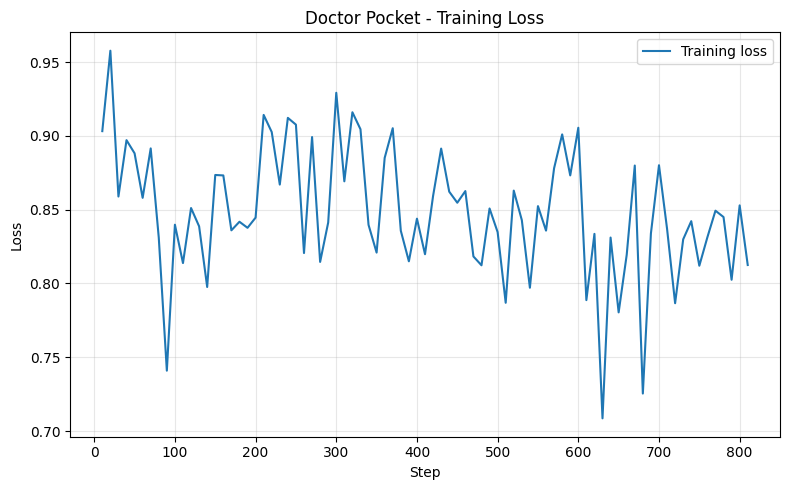

Saved: /content/training_loss.png (81 points)


In [34]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]

eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses = [x["eval_loss"] for x in log_history if "eval_loss" in x]

# --- Training loss plot ---
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Training loss", color="tab:blue")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Doctor Pocket - Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/training_loss.png", dpi=150)
plt.show()

print(f"Saved: /content/training_loss.png ({len(train_losses)} points)")


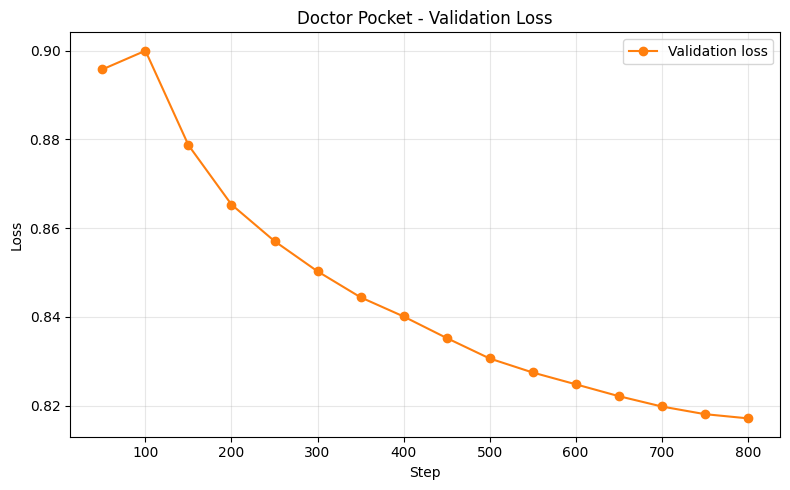

Saved: /content/validation_loss.png (16 points)


In [35]:
if eval_losses:
    plt.figure(figsize=(8, 5))
    plt.plot(eval_steps, eval_losses, label="Validation loss", color="tab:orange", marker="o")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Doctor Pocket - Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/validation_loss.png", dpi=150)
    plt.show()
    print(f"Saved: /content/validation_loss.png ({len(eval_losses)} points)")
else:
    print("No validation loss was logged (unexpected - check eval_strategy in SFTConfig).")


## 16. Test Set Evaluation

This is the **first and only** time the test set is used. We generate answers for a subset of test
questions and compare them against the reference answers.

**Important caveat on metrics**: we report ROUGE scores because they're a standard, cheap
text-overlap metric, but **ROUGE (and BLEU) do not measure medical correctness or safety** — a
generated answer can score well on ROUGE while being medically wrong, or score poorly while being an
equally valid answer phrased differently. Treat these numbers as a rough signal of *fluency and
lexical overlap* with the reference, not as a clinical accuracy score. Real validation of medical
correctness would require expert clinical review, which is out of scope for this notebook.


In [38]:
# Configurable number of test examples to actually run inference on (keeps this section fast)
N_TEST_SAMPLES = 5

model.eval()
model.config.use_cache = True  # safe to re-enable now that we are done training

test_subset = raw_datasets["test"].shuffle(seed=SEED).select(range(min(N_TEST_SAMPLES, len(raw_datasets["test"]))))

def generate_answer(question: str, max_new_tokens: int = 256) -> str:
    prompt = build_prompt_only(question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
        )
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

results = []
for i, ex in enumerate(test_subset):
    question = ex[QUESTION_COLUMN]
    reference = ex[ANSWER_COLUMN]
    generated = generate_answer(question)
    results.append({"question": question, "reference_answer": reference, "generated_answer": generated})
    if (i + 1) % 20 == 0:
        print(f"Generated {i + 1}/{len(test_subset)}...")

print(f"\nFinished generating {len(results)} test answers.")



Finished generating 5 test answers.


In [39]:
import evaluate

rouge = evaluate.load("rouge")
predictions = [r["generated_answer"] for r in results]
references = [r["reference_answer"] for r in results]

rouge_scores = rouge.compute(predictions=predictions, references=references)

print("ROUGE scores (lexical overlap with reference answers - NOT a medical-correctness metric):")
for k, v in rouge_scores.items():
    print(f"  {k}: {v:.4f}")


ROUGE scores (lexical overlap with reference answers - NOT a medical-correctness metric):
  rouge1: 0.3563
  rouge2: 0.1833
  rougeL: 0.2685
  rougeLsum: 0.3039


In [40]:
# Show a handful of qualitative examples
import textwrap

print("=" * 70)
print("SAMPLE TEST SET PREDICTIONS")
print("=" * 70)

for r in results[:5]:
    print("\nQUESTION:")
    print(textwrap.fill(r["question"], 90))
    print("\nREFERENCE:")
    print(textwrap.fill(r["reference_answer"][:500], 90))
    print("\nMODEL:")
    print(textwrap.fill(r["generated_answer"][:500], 90))
    print("-" * 70)


SAMPLE TEST SET PREDICTIONS

QUESTION:
What are the treatments for Peripheral Neuropathy ?

REFERENCE:
No medical treatments exist that can cure inherited peripheral neuropathy. However, there
are therapies for many other forms. In general, adopting healthy habits -- such as
maintaining optimal weight, avoiding exposure to toxins, following a physician-supervised
exercise program, eating a balanced diet, correcting vitamin deficiencies, and limiting or
avoiding alcohol consumption -- can reduce the physical and emotional effects of
peripheral neuropathy. Systemic diseases frequently require more

MODEL:
There is no cure for peripheral neuropathy; however, treatment options can relieve
symptoms and prevent complications. Treatment depends on which type of nerve damage you
have.                  Treatment may include                  - medicines that help with
pain  - medicines that slow down nerves' activity  - physical therapy or exercise   -
vitamin supplements                  Medici

## 17. Important Medical Safety Note

**Doctor Pocket is an educational / research prototype.** It is fine-tuned on public consumer-health
Q&A text. It is **not**:

- A licensed medical device.
- A replacement for a qualified physician, nurse, or pharmacist.
- Validated for clinical accuracy, safety, or completeness.

It **can** produce fluent-sounding but factually wrong or incomplete medical information (a
well-documented failure mode of LLMs known as hallucination), especially on rare conditions,
drug interactions, or dosing — areas that carry real-world risk if acted on incorrectly.

This is why the exact same system prompt is used consistently at training time (Section 9) and at
every inference point in this notebook and in the FastAPI backend (Sections 21-23):

```
You are Doctor Pocket, an AI medical information assistant.
Provide clear, cautious, educational medical information.
Do not claim to replace a doctor.
For emergencies or serious symptoms, advise the user to seek professional medical care.
Do not invent medical facts.
```

Any product built on top of this model should keep this framing visible to end users, and should
route anything resembling a medical emergency to real emergency services, not to the model.


## 18. Save the Fine-Tuned Model

We save the **LoRA adapter** (not a full copy of the base model - that would be ~3GB for no reason,
since the base model is unmodified and can always be re-downloaded from the Hub) plus the tokenizer,
and write out a README and JSON config files documenting exactly how this run was produced. This
metadata is what makes the model usable and reproducible later, e.g. by the FastAPI backend in
Section 23, or by anyone else picking up this project.


In [41]:
import json
import datetime

ADAPTER_DIR = "/content/doctor_pocket_qwen25_1_5b_lora"
os.makedirs(ADAPTER_DIR, exist_ok=True)

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"Adapter and tokenizer saved to: {ADAPTER_DIR}")
print("Contents:")
for f in sorted(os.listdir(ADAPTER_DIR)):
    fsize = os.path.getsize(os.path.join(ADAPTER_DIR, f))
    print(f"  {f}  ({fsize / 1024:.1f} KB)")


Adapter and tokenizer saved to: /content/doctor_pocket_qwen25_1_5b_lora
Contents:
  README.md  (5.1 KB)
  adapter_config.json  (1.0 KB)
  adapter_model.safetensors  (72178.8 KB)
  added_tokens.json  (0.6 KB)
  chat_template.jinja  (2.4 KB)
  merges.txt  (1632.7 KB)
  special_tokens_map.json  (0.6 KB)
  tokenizer.json  (11154.2 KB)
  tokenizer_config.json  (4.6 KB)
  vocab.json  (2711.8 KB)


In [42]:
# --- Save structured metadata: training config, LoRA config, dataset info ---
training_config = {
    "base_model": MODEL_NAME,
    "fine_tuning_method": "QLoRA (4-bit NF4 + LoRA adapters)",
    "dataset": {
        "source_file": "MedicalQuestionAnswering.csv",
        "total_examples_after_cleaning": len(split_df),
        "train_examples": len(train_df),
        "validation_examples": len(val_df),
        "test_examples": len(test_df),
        "split_seed": SEED,
        "question_column": QUESTION_COLUMN,
        "answer_column": ANSWER_COLUMN,
        "topic_column": TOPIC_COLUMN,
    },
    "lora_config": {
        "r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "target_modules": LORA_TARGET_MODULES,
    },
    "training_args": {
        "num_train_epochs": NUM_EPOCHS,
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": effective_batch_size,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "max_seq_length": MAX_SEQ_LENGTH,
        "precision": "fp16",
        "quantization": "4-bit NF4, double quantization",
        "optimizer": "paged_adamw_8bit",
    },
    "results": {
        "final_training_loss": train_result.training_loss,
        "training_time_minutes": round(_elapsed_minutes, 2),
        "rouge_scores": rouge_scores,
        "n_test_samples_evaluated": len(results),
    },
    "training_date_utc": datetime.datetime.utcnow().isoformat(),
    "system_prompt": DOCTOR_POCKET_SYSTEM_PROMPT,
}

with open(os.path.join(ADAPTER_DIR, "training_config.json"), "w") as f:
    json.dump(training_config, f, indent=2)

print("Saved training_config.json:")
print(json.dumps(training_config, indent=2))


Saved training_config.json:
{
  "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
  "fine_tuning_method": "QLoRA (4-bit NF4 + LoRA adapters)",
  "dataset": {
    "source_file": "MedicalQuestionAnswering.csv",
    "total_examples_after_cleaning": 16358,
    "train_examples": 13086,
    "validation_examples": 1636,
    "test_examples": 1636,
    "split_seed": 42,
    "question_column": "Question",
    "answer_column": "Answer",
    "topic_column": "topic"
  },
  "lora_config": {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "o_proj",
      "gate_proj",
      "up_proj",
      "down_proj"
    ]
  },
  "training_args": {
    "num_train_epochs": 1,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "effective_batch_size": 16,
    "learning_rate": 0.0002,
    "warmup_ratio": 0.03,
    "weight_decay": 0.01,
    "max_seq_length": 1024,
    "precision": "fp16",
    "quantization": 

/tmp/ipykernel_4087/1729579003.py:41: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date_utc": datetime.datetime.utcnow().isoformat(),


In [43]:
# --- README for the adapter directory ---
readme_content = f"""# Doctor Pocket - Qwen2.5-1.5B-Instruct LoRA Adapter

## Overview
Doctor Pocket is a **research / educational prototype** medical question-answering assistant.
It is a QLoRA fine-tune of `{MODEL_NAME}` and is **not** a substitute for professional medical advice.

## Base model
- `{MODEL_NAME}`

## Fine-tuning method
- QLoRA: base model loaded in 4-bit NF4 (double quantization), LoRA adapters trained in fp16.
- LoRA rank: {LORA_R}, alpha: {LORA_ALPHA}, dropout: {LORA_DROPOUT}
- Target modules: {", ".join(LORA_TARGET_MODULES)}

## Dataset
- Source: `MedicalQuestionAnswering.csv` ({len(split_df):,} examples after cleaning)
- Split: {len(train_df):,} train / {len(val_df):,} validation / {len(test_df):,} test (80/10/10, stratified by topic, seed={SEED})

## Training
- Epochs: {NUM_EPOCHS}
- Effective batch size: {effective_batch_size} (per-device {PER_DEVICE_TRAIN_BATCH_SIZE} x {GRADIENT_ACCUMULATION_STEPS} accumulation)
- Learning rate: {LEARNING_RATE}
- Sequence length: {MAX_SEQ_LENGTH}
- Final training loss: {train_result.training_loss:.4f}
- Training time: {_elapsed_minutes:.1f} minutes
- Training date: {datetime.datetime.utcnow().isoformat()} UTC

## Inference instructions
Load the base model in 4-bit (or fp16) and apply this adapter with PEFT:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained("{MODEL_NAME}", device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("{ADAPTER_DIR}")
model = PeftModel.from_pretrained(base_model, "{ADAPTER_DIR}")

messages = [
    {{"role": "system", "content": "You are Doctor Pocket, an AI medical information assistant. Provide clear, cautious, educational medical information. Do not claim to replace a doctor. For emergencies or serious symptoms, advise the user to seek professional medical care. Do not invent medical facts."}},
    {{"role": "user", "content": "What are common symptoms of iron deficiency anemia?"}},
]
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
output = model.generate(**inputs, max_new_tokens=256)
print(tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True))
```

See `backend/` (Section 23 of the training notebook) for a ready-to-run FastAPI server built on top
of this exact adapter.

## ⚠️ Medical safety warning
This is a research/educational medical assistant. It has **not** been clinically validated.
Do not use it for real diagnosis, treatment decisions, or in place of professional medical care.
For emergencies, contact real emergency services.
"""

with open(os.path.join(ADAPTER_DIR, "README.md"), "w") as f:
    f.write(readme_content)

print(readme_content)


# Doctor Pocket - Qwen2.5-1.5B-Instruct LoRA Adapter

## Overview
Doctor Pocket is a **research / educational prototype** medical question-answering assistant.
It is a QLoRA fine-tune of `Qwen/Qwen2.5-1.5B-Instruct` and is **not** a substitute for professional medical advice.

## Base model
- `Qwen/Qwen2.5-1.5B-Instruct`

## Fine-tuning method
- QLoRA: base model loaded in 4-bit NF4 (double quantization), LoRA adapters trained in fp16.
- LoRA rank: 16, alpha: 32, dropout: 0.05
- Target modules: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj

## Dataset
- Source: `MedicalQuestionAnswering.csv` (16,358 examples after cleaning)
- Split: 13,086 train / 1,636 validation / 1,636 test (80/10/10, stratified by topic, seed=42)

## Training
- Epochs: 1
- Effective batch size: 16 (per-device 2 x 8 accumulation)
- Learning rate: 0.0002
- Sequence length: 1024
- Final training loss: 0.8481
- Training time: 192.9 minutes
- Training date: 2026-08-08T14:01:16.785524 UTC

## Inference in

/tmp/ipykernel_4087/1782695187.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  - Training date: {datetime.datetime.utcnow().isoformat()} UTC


## 19. Merge LoRA with Base Model (Optional)

**LoRA adapter vs merged model — what's the difference?**

- **LoRA adapter** (what we saved in Section 18): a small set of extra matrices (a few tens of MB)
  that get combined with the *frozen, unmodified* base model at load time. Deployment requires
  loading the base model + applying the adapter via PEFT.
- **Merged model**: the adapter's weights are mathematically folded directly into the base model's
  own weights, producing a single standalone model. No PEFT needed at inference time, but it's a full
  model checkpoint (~3GB in fp16 for a 1.5B model) and merging temporarily requires holding the model
  in a higher-precision dtype in memory.

**For deployment we prioritize the saved adapter** from Section 18 — it's smaller, faster to
save/download, and the FastAPI backend in Section 23 is built to load base model + adapter directly.
Merging is provided here as an *optional* convenience for cases where you want a single self-contained
checkpoint (e.g. to upload one artifact to the Hub). We only attempt it if there's enough free VRAM,
and we explicitly do not fail the rest of the notebook if it doesn't fit.


In [44]:
MERGE_LORA = True  # set to False to skip merging entirely

merged_model_saved = False

if MERGE_LORA:
    free_vram_gb = (torch.cuda.get_device_properties(0).total_memory
                     - torch.cuda.memory_allocated(0)) / (1024 ** 3)
    print(f"Free VRAM before merge attempt: {free_vram_gb:.1f} GB")

    if free_vram_gb < 4:
        print("Skipping merge: less than 4GB free VRAM - too risky on a T4. "
              "The saved adapter from Section 18 is sufficient for deployment.")
    else:
        try:
            MERGED_DIR = "/content/doctor_pocket_qwen25_1_5b_merged"
            os.makedirs(MERGED_DIR, exist_ok=True)

            # Reload the base model in fp16 (not 4-bit) so the merge produces clean fp16 weights
            merge_base = AutoModelForCausalLM.from_pretrained(
                MODEL_NAME, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True,
            )
            from peft import PeftModel
            merge_model = PeftModel.from_pretrained(merge_base, ADAPTER_DIR)
            merged = merge_model.merge_and_unload()

            merged.save_pretrained(MERGED_DIR, safe_serialization=True)
            tokenizer.save_pretrained(MERGED_DIR)

            merged_model_saved = True
            print(f"Merged model saved to: {MERGED_DIR}")

            # Free the extra copy of the model we just created for merging
            del merge_base, merge_model, merged
            torch.cuda.empty_cache()
        except torch.cuda.OutOfMemoryError:
            print("Out of memory while merging - this is fine, skipping. "
                  "Deploy using base model + LoRA adapter instead (see Section 23).")
            torch.cuda.empty_cache()
else:
    print("MERGE_LORA is False - skipping. Deploy using base model + LoRA adapter (Section 23).")

print(f"\nmerged_model_saved = {merged_model_saved}")


`torch_dtype` is deprecated! Use `dtype` instead!


Free VRAM before merge attempt: 12.9 GB
Merged model saved to: /content/doctor_pocket_qwen25_1_5b_merged

merged_model_saved = True


## 20. Zip the Model

We zip the LoRA adapter directory (the artifact needed for deployment) so it can be downloaded as a
single file in the next section.


In [45]:
import zipfile

ZIP_PATH = "/content/doctor_pocket_qwen25_1_5b.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(ADAPTER_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            arcname = os.path.join("doctor_pocket_qwen25_1_5b", os.path.relpath(fpath, ADAPTER_DIR))
            zf.write(fpath, arcname)

zip_size_mb = os.path.getsize(ZIP_PATH) / (1024 ** 2)
print(f"Created: {ZIP_PATH}")
print(f"Zip file size: {zip_size_mb:.1f} MB")

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    print("\nContents:")
    for name in zf.namelist():
        print(f"  {name}")


Created: /content/doctor_pocket_qwen25_1_5b.zip
Zip file size: 69.0 MB

Contents:
  doctor_pocket_qwen25_1_5b/tokenizer_config.json
  doctor_pocket_qwen25_1_5b/training_config.json
  doctor_pocket_qwen25_1_5b/added_tokens.json
  doctor_pocket_qwen25_1_5b/vocab.json
  doctor_pocket_qwen25_1_5b/adapter_config.json
  doctor_pocket_qwen25_1_5b/adapter_model.safetensors
  doctor_pocket_qwen25_1_5b/special_tokens_map.json
  doctor_pocket_qwen25_1_5b/tokenizer.json
  doctor_pocket_qwen25_1_5b/merges.txt
  doctor_pocket_qwen25_1_5b/chat_template.jinja
  doctor_pocket_qwen25_1_5b/README.md


## 21. Google Colab Download

Run the cell below to download the ZIP archive directly to your computer via the browser.


In [46]:
try:
    from google.colab import files
    files.download(ZIP_PATH)
    print(f"Download triggered for {ZIP_PATH}")
except ImportError:
    print("Not running in Google Colab - google.colab.files is unavailable.")
    print(f"The archive is available locally at: {ZIP_PATH}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for /content/doctor_pocket_qwen25_1_5b.zip


## 22. Final Inference Test

The real test of "did saving actually work?" is reloading the adapter **from disk** (not reusing the
in-memory `model` object) and running inference. This proves the saved artifact in
`ADAPTER_DIR` is self-sufficient for deployment.


In [47]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import torch as _torch

# Reload everything fresh from disk to prove the saved adapter is standalone-usable
_reload_bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=_torch.float16,
)

reloaded_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=_reload_bnb_config, device_map="auto", trust_remote_code=True,
)
reloaded_tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
reloaded_model = PeftModel.from_pretrained(reloaded_base, ADAPTER_DIR)
reloaded_model.eval()

print("Reloaded base model + LoRA adapter from disk successfully.")


Reloaded base model + LoRA adapter from disk successfully.


In [48]:
sample_question = "What are common symptoms of iron deficiency anemia?"

messages = [
    {"role": "system", "content": DOCTOR_POCKET_SYSTEM_PROMPT},
    {"role": "user", "content": sample_question},
]
prompt = reloaded_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = reloaded_tokenizer(prompt, return_tensors="pt").to(reloaded_model.device)

with _torch.no_grad():
    output_ids = reloaded_model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=reloaded_tokenizer.pad_token_id,
    )

answer = reloaded_tokenizer.decode(
    output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
).strip()

print("USER:")
print(sample_question)
print("\nDOCTOR POCKET:")
print(answer)


USER:
What are common symptoms of iron deficiency anemia?

DOCTOR POCKET:
The most common symptom of iron deficiency anemia is fatigue (tiredness). Other signs and symptoms may include:
                
Pale skin
                
Shortness of breath or rapid heartbeat
                
Headache
                
Dizziness
                
Cold hands and feet
                
Muscle cramps or weakness
                
Pain in the upper right abdomen (the area between the breastbone and the navel) caused by bleeding in the stomach or intestines
                
A cough that produces sputum (mucus)
                
Bleeding gums
                
Decreased sex drive in women


**Checkpoint:** if you see a coherent, medically-cautious answer above, the saved adapter is
confirmed to work end-to-end from a fresh reload — exactly what the FastAPI backend in the next
section will do.

## 23. FastAPI Deployment Preparation

This notebook's job ends at producing a usable model artifact - the actual React frontend is a
separate project. But we generate a ready-to-run **FastAPI backend scaffold** here so the saved
adapter can be plugged in immediately, without hand-writing loading code from scratch.

We write out a `backend/` folder next to the adapter:

```
doctor_pocket_qwen25_1_5b_lora/   <- the adapter saved in Section 18
backend/
    model_loader.py               <- loads base model + adapter ONCE at startup
    main.py                       <- FastAPI app, exposes POST /generate
    requirements.txt              <- pinned deployment dependencies
```

The API contract is intentionally simple, matching what a React frontend would call:

```
POST /generate
{ "question": "What are the symptoms of anemia?" }

-> 200 OK
{ "answer": "..." }
```

`model_loader.py` loads the model **once**, at process startup (not per-request) — this is the
single most important performance detail for a backend serving an LLM, since loading a quantized
model takes several seconds and should never happen inside a request handler.


In [49]:
BACKEND_DIR = "/content/backend"
os.makedirs(BACKEND_DIR, exist_ok=True)

model_loader_code = f'''"""
model_loader.py - loads the Doctor Pocket base model + LoRA adapter ONCE at process startup.

Import `get_model_and_tokenizer()` from this module in main.py - it lazily loads the model
on first call and caches it in memory for the lifetime of the process, so subsequent requests
reuse the already-loaded model instead of reloading it.
"""
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL_NAME = "{MODEL_NAME}"
ADAPTER_PATH = "./doctor_pocket_qwen25_1_5b_lora"  # copy the adapter folder next to this backend

DOCTOR_POCKET_SYSTEM_PROMPT = (
    {DOCTOR_POCKET_SYSTEM_PROMPT!r}
)

_model = None
_tokenizer = None


def get_model_and_tokenizer():
    """Returns the (model, tokenizer) tuple, loading them on first call only."""
    global _model, _tokenizer

    if _model is not None:
        return _model, _tokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[model_loader] Loading Doctor Pocket model on device={{device}} ...")

    if device == "cuda":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        base_model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL_NAME, quantization_config=bnb_config, device_map="auto",
            trust_remote_code=True,
        )
    else:
        # CPU fallback: no bitsandbytes 4-bit support on CPU, load in fp32 instead.
        # Expect this to be slow - CPU inference is a fallback for local testing, not production.
        print("[model_loader] WARNING: No GPU found, falling back to CPU (fp32). This will be slow.")
        base_model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL_NAME, torch_dtype=torch.float32, trust_remote_code=True,
        )

    tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)
    model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    model.eval()

    _model, _tokenizer = model, tokenizer
    print("[model_loader] Model loaded and cached.")
    return _model, _tokenizer


def generate_answer(question: str, max_new_tokens: int = 256) -> str:
    """Generates a Doctor Pocket answer for a single question."""
    model, tokenizer = get_model_and_tokenizer()

    messages = [
        {{"role": "system", "content": DOCTOR_POCKET_SYSTEM_PROMPT}},
        {{"role": "user", "content": question}},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()
'''

with open(os.path.join(BACKEND_DIR, "model_loader.py"), "w") as f:
    f.write(model_loader_code)

print(f"Wrote {os.path.join(BACKEND_DIR, 'model_loader.py')}")


Wrote /content/backend/model_loader.py


In [50]:
main_py_code = '''"""
main.py - FastAPI backend for Doctor Pocket.

Run locally with:
    uvicorn main:app --host 0.0.0.0 --port 8000

Exposes:
    POST /generate   {"question": "..."} -> {"answer": "..."}
    GET  /health      simple liveness check
"""
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

from model_loader import get_model_and_tokenizer, generate_answer

app = FastAPI(title="Doctor Pocket API", version="1.0.0")


class GenerateRequest(BaseModel):
    question: str


class GenerateResponse(BaseModel):
    answer: str


@app.on_event("startup")
def load_model_on_startup():
    # Load the model once here, so the FIRST real request isn\'t the one paying the load cost.
    get_model_and_tokenizer()


@app.get("/health")
def health():
    return {"status": "ok"}


@app.post("/generate", response_model=GenerateResponse)
def generate(request: GenerateRequest):
    question = request.question.strip()
    if not question:
        raise HTTPException(status_code=400, detail="\'question\' must not be empty.")

    try:
        answer = generate_answer(question)
    except Exception as e:
        # Do not leak internal stack traces to the client; log server-side instead.
        print(f"[main] Generation error: {e}")
        raise HTTPException(status_code=500, detail="Failed to generate an answer. Please try again.")

    return GenerateResponse(answer=answer)
'''

with open(os.path.join(BACKEND_DIR, "main.py"), "w") as f:
    f.write(main_py_code)

print(f"Wrote {os.path.join(BACKEND_DIR, 'main.py')}")


Wrote /content/backend/main.py


### Deployment `requirements.txt`

Pinned to versions compatible with what we used in this notebook (not "latest"), plus the FastAPI
serving stack.


In [51]:
requirements_txt = """torch==2.5.1
transformers==4.46.3
peft==0.13.2
accelerate==1.1.1
bitsandbytes==0.44.1
fastapi==0.115.5
uvicorn[standard]==0.32.1
pydantic==2.9.2
"""

with open(os.path.join(BACKEND_DIR, "requirements.txt"), "w") as f:
    f.write(requirements_txt)

print(f"Wrote {os.path.join(BACKEND_DIR, 'requirements.txt')}")
print("\n" + requirements_txt)

print("=" * 60)
print("Deployment scaffold ready:")
for f in sorted(os.listdir(BACKEND_DIR)):
    print(f"  backend/{f}")
print(f"\nTo deploy: copy both '{ADAPTER_DIR}' and '{BACKEND_DIR}' to your server, "
      f"pip install -r backend/requirements.txt, then run "
      f"'uvicorn main:app --host 0.0.0.0 --port 8000' from inside backend/ "
      f"(with the adapter folder placed alongside it, matching ADAPTER_PATH in model_loader.py).")
print("=" * 60)


Wrote /content/backend/requirements.txt

torch==2.5.1
transformers==4.46.3
peft==0.13.2
accelerate==1.1.1
bitsandbytes==0.44.1
fastapi==0.115.5
uvicorn[standard]==0.32.1
pydantic==2.9.2

Deployment scaffold ready:
  backend/main.py
  backend/model_loader.py
  backend/requirements.txt

To deploy: copy both '/content/doctor_pocket_qwen25_1_5b_lora' and '/content/backend' to your server, pip install -r backend/requirements.txt, then run 'uvicorn main:app --host 0.0.0.0 --port 8000' from inside backend/ (with the adapter folder placed alongside it, matching ADAPTER_PATH in model_loader.py).


### Wiring up the React frontend (outside the scope of this notebook)

Once the FastAPI backend above is running, a React frontend just needs to `POST` to `/generate`:

```javascript
const res = await fetch("http://localhost:8000/generate", {
  method: "POST",
  headers: { "Content-Type": "application/json" },
  body: JSON.stringify({ question: userInput }),
});
const { answer } = await res.json();
```

That's the entire integration surface — everything upstream of it (quantization, LoRA, chat
templates, generation parameters) is already handled inside `model_loader.py`.
